# Few-Shot Learning using Model-Agnostic Meta-Learning (MAML)
This notebook trains and evaluates four architectures (CNN, CNN+Attention, CNN+Mamba, CNN+Attention+Mamba) on the HyperLeaf spectral dataset using Model-Agnostic Meta-Learning (specifically First-Order MAML, FOMAML).


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Configure GPU memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("GPU configuration error:", e)

# Parameters
NUM_BANDS = 204
NUM_STATS = 5

# Load dataset
loaded_data = np.load("hyperleaf_processed.npz")
X_data = loaded_data['X']
y_data = loaded_data['y']

# Stratified train/val/test split
X_train_raw, X_temp, y_train, y_temp = train_test_split(
    X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Normalize data
X_min = X_train_raw.min()
X_max = X_train_raw.max()
X_train = (X_train_raw - X_min) / (X_max - X_min + 1e-8)
X_test = (X_test_raw - X_min) / (X_max - X_min + 1e-8)

# Function to sample episodic few-shot batches
def get_few_shot_episode(X, y, n_way=4, k_shot=10, q_query=5):
    unique_classes = np.unique(y)
    selected_classes = unique_classes[:n_way]
    support_x, support_y, query_x, query_y = [], [], [], []
    for label_idx, c in enumerate(selected_classes):
        class_indices = np.where(y == c)[0]
        sampled_indices = np.random.choice(class_indices, k_shot + q_query, replace=False)
        support_x.append(X[sampled_indices[:k_shot]])
        support_y.append(np.full((k_shot,), label_idx))
        query_x.append(X[sampled_indices[k_shot:]])
        query_y.append(np.full((q_query,), label_idx))
    support_x = np.concatenate(support_x, axis=0)
    support_y = np.concatenate(support_y, axis=0)
    query_x = np.concatenate(query_x, axis=0)
    query_y = np.concatenate(query_y, axis=0)
    shuffle_idx = np.random.permutation(len(query_y))
    query_x = query_x[shuffle_idx]
    query_y = query_y[shuffle_idx]
    return (tf.convert_to_tensor(support_x, dtype=tf.float32),
            tf.convert_to_tensor(support_y, dtype=tf.int32),
            tf.convert_to_tensor(query_x, dtype=tf.float32),
            tf.convert_to_tensor(query_y, dtype=tf.int32))

class MAMLClassifier(tf.keras.Model):
    def __init__(self, encoder, n_way=4):
        super(MAMLClassifier, self).__init__()
        self.encoder = encoder
        self.classifier_head = layers.Dense(n_way, activation=None)
    def call(self, x, training=True):
        embeddings = self.encoder(x, training=training)
        logits = self.classifier_head(embeddings)
        return logits

def train_step_fomaml(model, optimizer, support_x, support_y, query_x, query_y, alpha=0.05):
    original_weights = [tf.identity(v) for v in model.trainable_variables]
    with tf.GradientTape() as inner_tape:
        support_preds = model(support_x, training=True)
        loss_support = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
            support_y, support_preds, from_logits=True
        ))
    grads_support = inner_tape.gradient(loss_support, model.trainable_variables)
    for var, grad in zip(model.trainable_variables, grads_support):
        if grad is not None:
            var.assign(var - alpha * grad)
            
    with tf.GradientTape() as outer_tape:
        query_preds = model(query_x, training=True)
        loss_query = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
            query_y, query_preds, from_logits=True
        ))
    grads_outer = outer_tape.gradient(loss_query, model.trainable_variables)
    
    for var, orig_val in zip(model.trainable_variables, original_weights):
        var.assign(orig_val)
        
    trainable_vars, applied_grads = [], []
    for var, grad in zip(model.trainable_variables, grads_outer):
        if grad is not None:
            trainable_vars.append(var)
            applied_grads.append(grad)
    optimizer.apply_gradients(zip(applied_grads, trainable_vars))
    preds = tf.argmax(query_preds, axis=-1, output_type=tf.int32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(preds, query_y), tf.float32))
    return loss_query, accuracy

def train_maml_model(maml_net, episodes=4000, lr=2e-4, alpha=0.01):
    optimizer = tf.keras.optimizers.Adam(lr)
    loss_history, acc_history = [], []
    for ep in range(1, episodes + 1):
        sx, sy, qx, qy = get_few_shot_episode(X_train, y_train, 4, 5, 5)
        loss, acc = train_step_fomaml(maml_net, optimizer, sx, sy, qx, qy, alpha=alpha)
        loss_history.append(loss.numpy())
        acc_history.append(acc.numpy())
        if ep % 200 == 0:
            print(f"  Episode {ep:4d} | Loss: {loss:.4f} | Accuracy: {acc*100:.2f}%")
    return loss_history, acc_history


In [2]:
# --- 1. CNN Architecture ---
def build_cnn_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x) # LN for MAML stability
    x = layers.Conv1D(128, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='leaky_relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Encoder")

cnn_encoder = build_cnn_encoder()
maml_cnn = MAMLClassifier(cnn_encoder, n_way=4)
print("Training CNN MAML...")
loss_cnn, acc_cnn = train_maml_model(maml_cnn, episodes=1000)
cnn_encoder.save("best_maml_cnn_encoder.keras")
maml_cnn.save_weights("best_maml_cnn_weights.h5")


Training CNN MAML...
  Episode  200 | Loss: 1.1088 | Accuracy: 50.00%
  Episode  400 | Loss: 1.2089 | Accuracy: 55.00%
  Episode  600 | Loss: 1.1856 | Accuracy: 50.00%
  Episode  800 | Loss: 1.0113 | Accuracy: 70.00%
  Episode 1000 | Loss: 0.9341 | Accuracy: 65.00%


In [3]:
# --- 2. CNN + Attention Architecture ---
def build_cnn_attention_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    # Attention block
    attn_out = layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.05)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='leaky_relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Attention_Encoder")

cnn_attention_encoder = build_cnn_attention_encoder()
maml_attention = MAMLClassifier(cnn_attention_encoder, n_way=4)
print("Training CNN+Attention MAML...")
loss_attention, acc_attention = train_maml_model(maml_attention, episodes=1000)
cnn_attention_encoder.save("best_maml_cnn_attention_encoder.keras")
maml_attention.save_weights("best_maml_cnn_attention_weights.h5")


Training CNN+Attention MAML...
  Episode  200 | Loss: 1.3417 | Accuracy: 40.00%
  Episode  400 | Loss: 1.1226 | Accuracy: 45.00%
  Episode  600 | Loss: 1.2049 | Accuracy: 55.00%
  Episode  800 | Loss: 1.2088 | Accuracy: 50.00%
  Episode 1000 | Loss: 0.9898 | Accuracy: 75.00%


In [4]:
# --- 3. CNN + Mamba Architecture ---
class StableMambaBlock(layers.Layer):
    def __init__(self, d_model, d_state=32, d_conv=4, expand=2, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(expand * d_model)

    def build(self, input_shape):
        self.in_proj = layers.Dense(self.d_inner * 2, use_bias=False)
        self.conv1d = layers.Conv1D(
            filters=self.d_inner, kernel_size=self.d_conv, padding='same', groups=self.d_inner, activation='swish'
        )
        self.x_proj = layers.Dense(self.d_state * 2 + self.d_inner, use_bias=False)
        self.dt_proj = layers.Dense(self.d_inner, activation='softplus')
        
        A_init_val = -np.log(np.arange(1, self.d_state + 1, dtype=np.float32))
        A_init_val = np.tile(A_init_val[np.newaxis, :], (self.d_inner, 1))
        A_init = tf.keras.initializers.Constant(A_init_val)
        self.A = self.add_weight(
            name="A",
            shape=(self.d_inner, self.d_state),
            initializer=A_init,
            trainable=True
        )
        
        self.D = self.add_weight(
            name="D",
            shape=(self.d_inner,),
            initializer=tf.keras.initializers.Ones(),
            trainable=True
        )
        
        self.out_proj = layers.Dense(self.d_model, use_bias=False)
        super().build(input_shape)

    def call(self, x):
        projected = self.in_proj(x)
        x_branch, res_branch = tf.split(projected, num_or_size_splits=2, axis=-1)
        x_branch = self.conv1d(x_branch)
        
        ssm_params = self.x_proj(x_branch)
        B, C, delta = tf.split(ssm_params, [self.d_state, self.d_state, self.d_inner], axis=-1)
        delta = self.dt_proj(delta)
        
        delta_expanded = tf.expand_dims(delta, axis=-1)
        A_expanded = tf.expand_dims(self.A, axis=0)
        A_expanded = tf.expand_dims(A_expanded, axis=0)
        
        A_bar = tf.exp(delta_expanded * A_expanded)
        
        B_expanded = tf.expand_dims(B, axis=2)
        B_bar = delta_expanded * B_expanded
        
        x_branch_expanded = tf.expand_dims(x_branch, axis=-1)
        inputs_ssm = B_bar * x_branch_expanded
        
        inputs_ssm = tf.transpose(inputs_ssm, perm=[1, 0, 2, 3])
        A_bar = tf.transpose(A_bar, perm=[1, 0, 2, 3])
        
        elems = (A_bar, inputs_ssm)
        batch_size = tf.shape(x)[0]
        h_0 = tf.zeros((batch_size, self.d_inner, self.d_state), dtype=tf.float32)
        
        def scan_fn(h_prev, elem):
            a_bar_t, ssm_in_t = elem
            return a_bar_t * h_prev + ssm_in_t
        
        h_seq = tf.scan(scan_fn, elems, initializer=h_0)
        h_seq = tf.transpose(h_seq, perm=[1, 0, 2, 3])
        
        C_expanded = tf.expand_dims(C, axis=2)
        y = tf.reduce_sum(h_seq * C_expanded, axis=-1)
        
        D_expanded = tf.reshape(self.D, (1, 1, self.d_inner))
        y = y + D_expanded * x_branch
        
        gated_output = y * tf.keras.activations.swish(res_branch)
        return self.out_proj(gated_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "d_state": self.d_state,
            "d_conv": self.d_conv,
            "expand": self.expand
        })
        return config

def build_cnn_mamba_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    mamba_out = StableMambaBlock(d_model=128, d_state=16, d_conv=4, expand=2)(x)
    x = layers.Add()([x, mamba_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='leaky_relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Mamba_Encoder")

cnn_mamba_encoder = build_cnn_mamba_encoder()
maml_mamba = MAMLClassifier(cnn_mamba_encoder, n_way=4)
print("Training CNN+Mamba MAML...")
loss_mamba, acc_mamba = train_maml_model(maml_mamba, episodes=1000)
cnn_mamba_encoder.save("best_maml_cnn_mamba_encoder.keras")
maml_mamba.save_weights("best_maml_cnn_mamba_weights.h5")


Training CNN+Mamba MAML...
  Episode  200 | Loss: 1.1502 | Accuracy: 45.00%
  Episode  400 | Loss: 1.0168 | Accuracy: 75.00%
  Episode  600 | Loss: 1.0277 | Accuracy: 70.00%
  Episode  800 | Loss: 0.8666 | Accuracy: 75.00%
  Episode 1000 | Loss: 0.9762 | Accuracy: 65.00%


In [5]:
# --- 4. CNN + Attention + Mamba Architecture ---
def build_cnn_attention_mamba_encoder(l2_reg=1e-4):
    inputs = layers.Input(shape=(NUM_BANDS, NUM_STATS))
    reg = tf.keras.regularizers.l2(l2_reg)
    x = layers.Conv1D(64, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    x = layers.Conv1D(128, kernel_size=5, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.LayerNormalization()(x)
    
    attn_out = layers.MultiHeadAttention(num_heads=2, key_dim=32, dropout=0.05)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization()(x)
    
    mamba_out = StableMambaBlock(d_model=128, d_state=16, d_conv=4, expand=2)(x)
    x = layers.Add()([x, mamba_out])
    x = layers.LayerNormalization()(x)
    
    x = layers.Conv1D(128, kernel_size=3, activation='leaky_relu', padding='same', kernel_regularizer=reg)(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='leaky_relu', kernel_regularizer=reg)(x)
    raw_embeddings = layers.Dense(32, activation=None)(x)
    normalized_embeddings = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=-1))(raw_embeddings)
    return models.Model(inputs=inputs, outputs=normalized_embeddings, name="CNN_Attention_Mamba_Encoder")

cnn_attention_mamba_encoder = build_cnn_attention_mamba_encoder()
maml_attn_mamba = MAMLClassifier(cnn_attention_mamba_encoder, n_way=4)
print("Training CNN+Attention+Mamba MAML...")
loss_attn_mamba, acc_attn_mamba = train_maml_model(maml_attn_mamba, episodes=1000)
cnn_attention_mamba_encoder.save("best_maml_cnn_attention_mamba_encoder.keras")
maml_attn_mamba.save_weights("best_maml_cnn_attention_mamba_weights.h5")


Training CNN+Attention+Mamba MAML...
  Episode  200 | Loss: 1.0692 | Accuracy: 65.00%
  Episode  400 | Loss: 0.9737 | Accuracy: 75.00%
  Episode  600 | Loss: 1.0167 | Accuracy: 50.00%
  Episode  800 | Loss: 0.9770 | Accuracy: 50.00%
  Episode 1000 | Loss: 0.8235 | Accuracy: 70.00%


In [2]:
# --- 5. Testing Cell (Holdout Evaluation) ---
# 5-Shot Holdout Evaluation over 100 trials for each model with adaptation
maml_models = {
    'CNN': maml_cnn,
    'CNN+Attention': maml_attention,
    'CNN+Mamba': maml_mamba,
    'CNN+Attention+Mamba': maml_attn_mamba
}

eval_results = {}

for name, maml_net in maml_models.items():
    print(f"\nEvaluating {name} MAML Model (Test-Time Adaptation)...")
    suffix = name.lower().replace('+', '_')
    try:
        maml_net.load_weights(f"best_maml_{suffix}_weights.h5")
    except Exception as e:
        print(f"No saved weights found for {name}, using current weights.")
        
    trial_accs = []
    for i in range(100):
        # Sample test episode (5 support, 5 query per class)
        sx, sy, qx, qy = get_few_shot_episode(X_test, y_test, 4, 5, 5)
        
        # Save pre-adaptation weights
        original_weights = [tf.identity(v) for v in maml_net.trainable_variables]
        
        # Adaptation steps (5 steps fine-tuning on support set)
        for _ in range(5):
            with tf.GradientTape() as tape:
                preds_support = maml_net(sx, training=False)
                loss_support = tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(
                    sy, preds_support, from_logits=True
                ))
            grads = tape.gradient(loss_support, maml_net.trainable_variables)
            for var, grad in zip(maml_net.trainable_variables, grads):
                if grad is not None:
                    var.assign(var - 0.01 * grad)
                    
        logits = maml_net(qx, training=False)
        preds = tf.argmax(logits, axis=-1, output_type=tf.int32)
        acc = tf.reduce_mean(tf.cast(tf.equal(preds, qy), tf.float32)).numpy()
        trial_accs.append(acc * 100.0)
        
        # Restore pre-adaptation weights
        for var, orig in zip(maml_net.trainable_variables, original_weights):
            var.assign(orig)
            
    mean_acc = np.mean(trial_accs)
    max_acc = np.max(trial_accs)
    min_acc = np.min(trial_accs)
    eval_results[name] = trial_accs
    
    print(f"5-Shot Holdout Test Accuracy over 100 trials:")
    print(f"  Mean Accuracy: {mean_acc:.2f}%")
    print(f"  Max Accuracy:  {max_acc:.2f}%")
    print(f"  Min Accuracy:  {min_acc:.2f}%")


NameError: name 'maml_cnn' is not defined

C:\Users\rosha\AppData\Local\Temp\ipykernel_6772\3507240839.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\rosha\AppData\Local\Temp\ipykernel_6772\3507240839.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


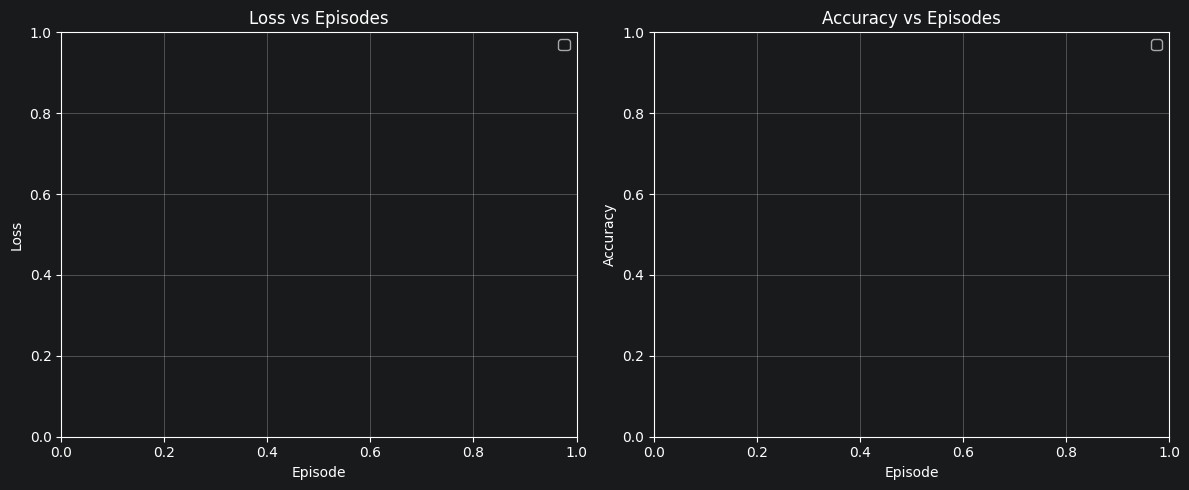

NameError: name 'eval_results' is not defined

In [3]:
# --- 6. Plotting Cell ---
import pandas as pd
# Plotting training curves and evaluation results
histories = {
    'CNN': (loss_cnn, acc_cnn) if 'loss_cnn' in locals() else None,
    'CNN+Attention': (loss_attention, acc_attention) if 'loss_attention' in locals() else None,
    'CNN+Mamba': (loss_mamba, acc_mamba) if 'loss_mamba' in locals() else None,
    'CNN+Attention+Mamba': (loss_attn_mamba, acc_attn_mamba) if 'loss_attn_mamba' in locals() else None
}

def smooth(y, window=50):
    return pd.Series(y).rolling(window, min_periods=1).mean()

# 1. Loss vs Episode
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for name, hist in histories.items():
    if hist:
        plt.plot(hist[0], alpha=0.3)
        plt.plot(smooth(hist[0]), label=f'{name}')
plt.title('Loss vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2. Accuracy vs Episode
plt.subplot(1, 2, 2)
for name, hist in histories.items():
    if hist:
        plt.plot(hist[1], alpha=0.3)
        plt.plot(smooth(hist[1]), label=f'{name}')
plt.title('Accuracy vs Episodes')
plt.xlabel('Episode')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Holdout Evaluation Distributions
if eval_results:
    plt.figure(figsize=(10, 6))
    data_to_plot = [eval_results[name] for name in eval_results]
    plt.boxplot(data_to_plot, tick_labels=list(eval_results.keys()))
    plt.title('5-Shot Holdout Test Accuracy Distribution (100 Trials)')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.show()
